# Section 5.2: RQ1
## Critical Difference Diagrams

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats, create_report, latex_table


INPUT_PATH = "../data/icpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv"
INPUT_PATH = "../data/icpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv"
INPUT_PATH = "../data/icpm_25/8fts_3miners_ind_ilp_sm1_3456_shapley.csv"


METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]

In [2]:
data = pd.read_csv(INPUT_PATH)
#features = pd.read_csv("../data/icpm_25/8fts_genEL_features.csv")
shapley = data[~data['metric'].isin(['benchtime', 'pnsize'])]
#shapley = data.copy()
print(shapley['algorithm'].unique())
print(shapley.shape)
shapley.head()

['inductive' 'sm1' 'ilp']
(90072, 5)


,algorithm,metric,feature_name,feature_value,shapley_value
5004,inductive,cfc,aq1,6413,11.833333
5005,inductive,cfc,svo,758,-5.166667
5006,inductive,cfc,tlv,2776,4.333333
5007,inductive,cfc,aq1,6413,9.833333
5008,inductive,cfc,svo,758,-4.166667


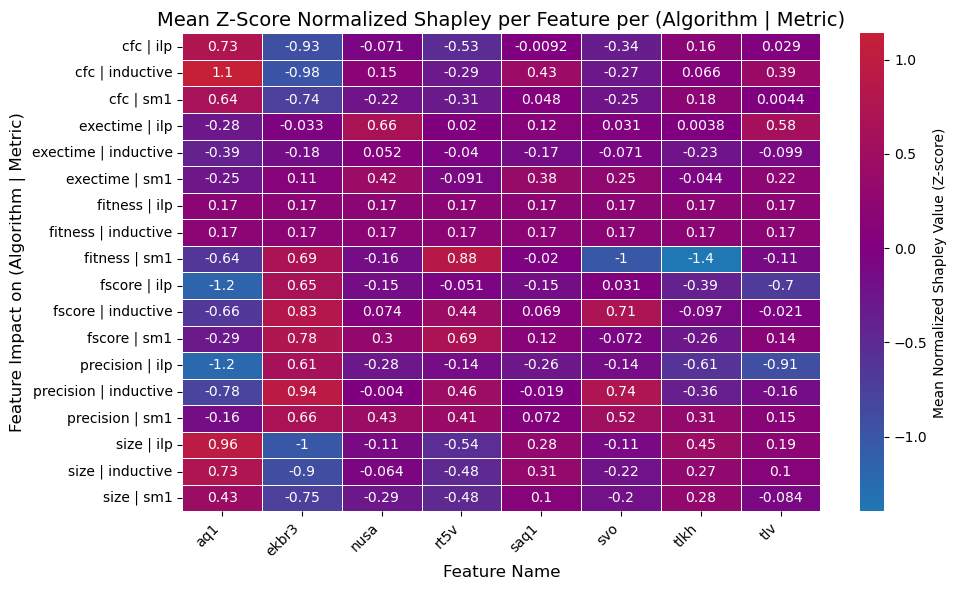

In [3]:
shap_blue = "#1F77B4"
shap_red = "#D62728"
colors = [shap_blue, "purple", shap_red]
custom_cmap = LinearSegmentedColormap.from_list("BluePurpleRed", colors, N=256)

# Copy original data
data = shapley.copy()

# Z-score normalization per metric
data['norm_shapley'] = data.groupby('metric')['shapley_value'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

# Combine algorithm and metric into one label
data['alg_metric'] = data['metric'] + " | " + data['algorithm']

# Prepare the heatmap matrix
features = sorted(data['feature_name'].unique())
alg_metrics = sorted(data['alg_metric'].unique())

heatmap_data = pd.DataFrame(index=alg_metrics, columns=features)

# Compute mean normalized shapley values
for alg_metric in alg_metrics:
    for feature in features:
        subset = data[(data['alg_metric'] == alg_metric) & (data['feature_name'] == feature)]
        if len(subset) > 0:
            mean_norm = subset['norm_shapley'].mean()
            heatmap_data.loc[alg_metric, feature] = mean_norm
        else:
            heatmap_data.loc[alg_metric, feature] = np.nan

# Convert to float
heatmap_data = heatmap_data.astype(float)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap=custom_cmap, center=0, linewidths=0.5,
            cbar_kws={"label": "Mean Normalized Shapley Value (Z-score)"})
plt.title("Mean Z-Score Normalized Shapley per Feature per (Algorithm | Metric)", fontsize=14)
plt.ylabel("Feature Impact on (Algorithm | Metric)", fontsize=12)
plt.xlabel("Feature Name", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [4]:
FONTSIZE = 18  # Set your preferred base font size

def run_cd_selection_autorank(data, filter_name='alg_metric', alg_metric_filter='cfc | inductive', alpha=0.05):
    """
    Filters the data by alg_metric, pivots shapley values into wide format by feature_name,
    runs autorank statistical analysis, creates report and plots the stats.
    
    Parameters:
    -----------
    data : pd.DataFrame
        Input dataframe containing at least columns: ['alg_metric', 'feature_name', 'shapley_value']
    alg_metric_filter : str
        The value of 'alg_metric' to filter on (default: 'cfc | inductive')
    alpha : float
        Significance level for autorank (default: 0.05)
        
    Returns:
    --------
    result : autorank.AutorankResults
        The result object from autorank analysis
    """
    # Filter rows by alg_metric
    cd_selection = data[data[filter_name] == alg_metric_filter]
    
    # Select needed columns and reset index
    cd_selection = cd_selection[['feature_name', 'feature_value', 'shapley_value']].reset_index(drop=True)
    
    # Create wide format dataframe with shapley values under feature_name columns
    df_wide = pd.get_dummies(cd_selection['feature_name'])
    for col in df_wide.columns:
        df_wide[col] = df_wide[col] * cd_selection['shapley_value']
    
    # Run autorank analysis
    result = autorank(df_wide, alpha=alpha, verbose=False)
    
    # Create and display report
    create_report(result)
    
    # Plot statistics (allow insignificant links to show)
    ax = plot_stats(result)  # could use allow_insignificant=True if desired
    #ax.set_title(alg_metric_filter, fontsize=int(FONTSIZE * 1.1))
    
    # Adjust axis label fonts (if present)
    ax.set_xlabel(ax.get_xlabel(), fontsize=int(FONTSIZE))
    ax.set_ylabel(ax.get_ylabel(), fontsize=int(FONTSIZE))
    
    # Adjust tick labels
    ax.tick_params(axis='x', labelsize=int(FONTSIZE))
    ax.tick_params(axis='y', labelsize=int(FONTSIZE))
    
    file_id = alg_metric_filter.replace(' | ', '_')
    plt.savefig(f"../output/plots/cd_{file_id}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    return result

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), svo (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), saq1 (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


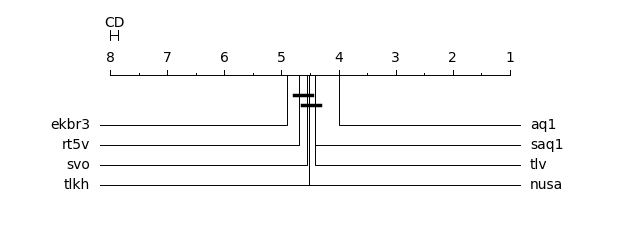

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations aq1 (p=0.000), rt5v (p=0.000), tlkh (p=0.000), nusa (p=0.000), saq1 (p=0.000), tlv (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


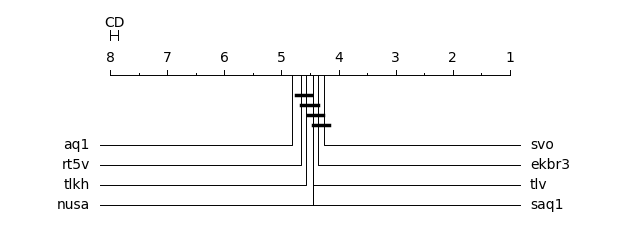

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


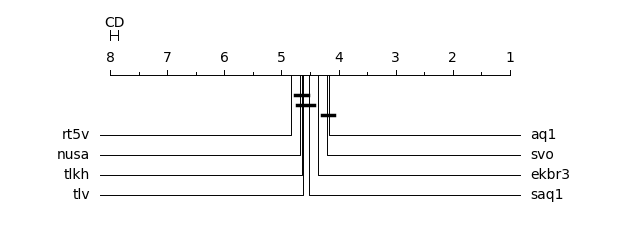

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), aq1 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


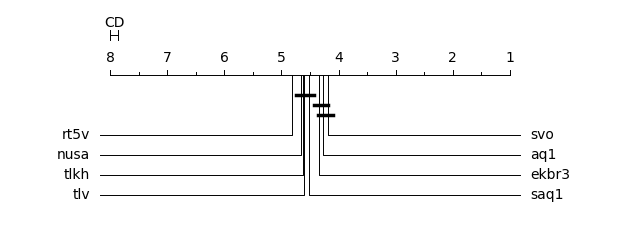

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlv (p=0.000), tlkh (p=0.000), saq1 (p=0.000), aq1 (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


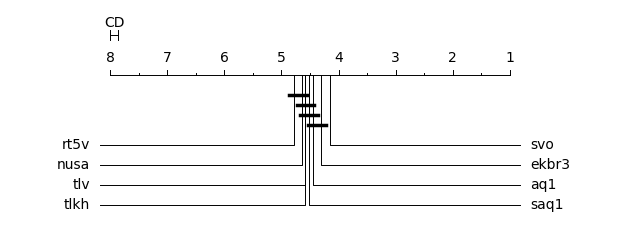

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


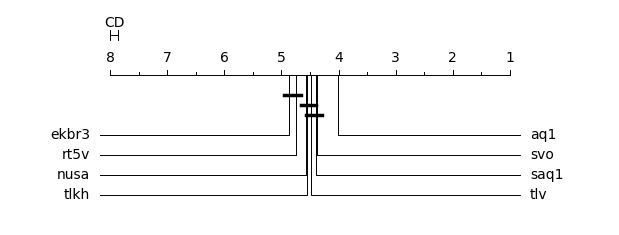

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), ekbr3 (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


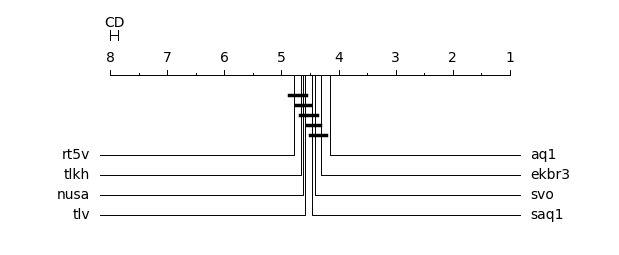

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


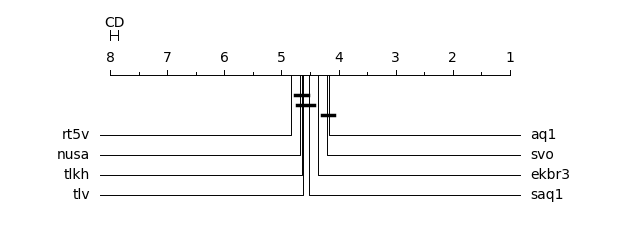

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


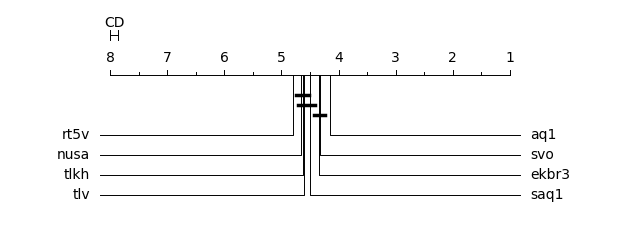

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), ekbr3 (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


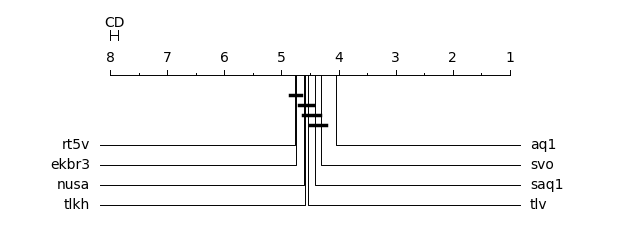

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


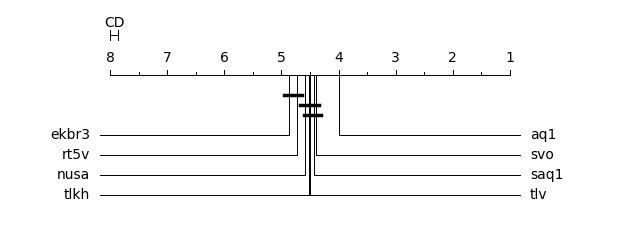

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), saq1 (p=0.000), aq1 (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


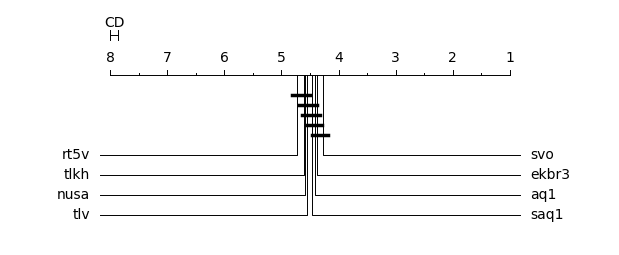

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


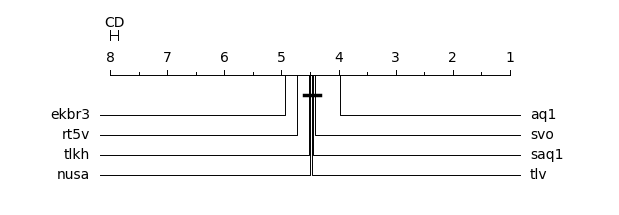

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations aq1 (p=0.000), rt5v (p=0.000), tlkh (p=0.000), ekbr3 (p=0.000), saq1 (p=0.000), nusa (p=0.000), svo (p=0.000), and tlv (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


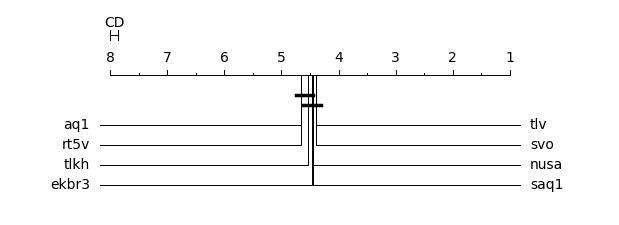

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


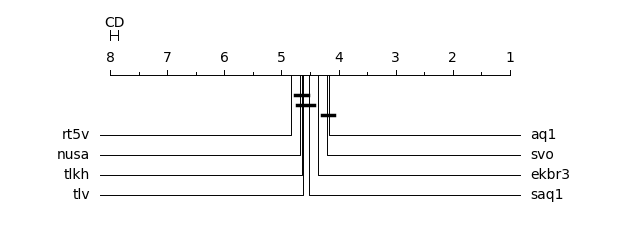

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), aq1 (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


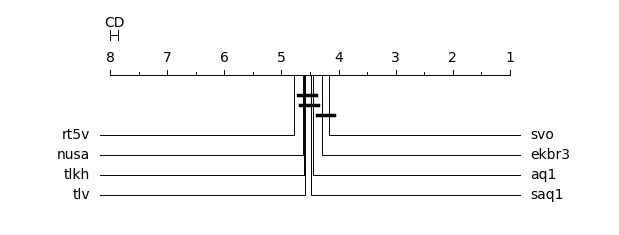

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), tlkh (p=0.000), tlv (p=0.000), aq1 (p=0.000), nusa (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


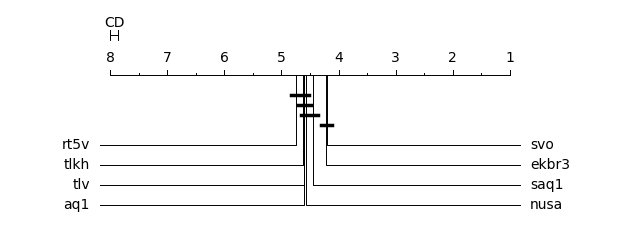

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5004.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 5004 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.14

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


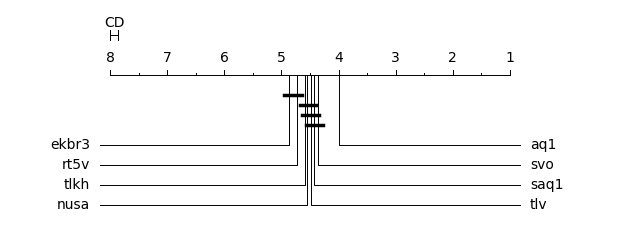

In [5]:
for alg_metric in data['alg_metric'].unique():
    run_cd_selection_autorank(data, alg_metric_filter=alg_metric, alpha=0.05)

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15012.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 15012 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), svo (p=0.000), saq1 (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


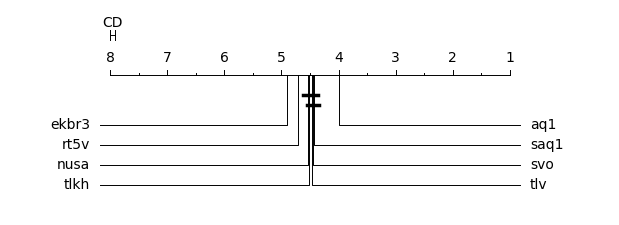

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15012.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 15012 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), aq1 (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


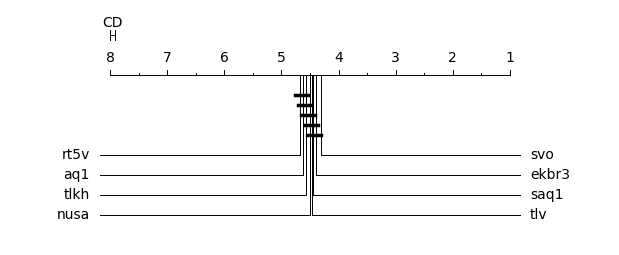

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15012.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 15012 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


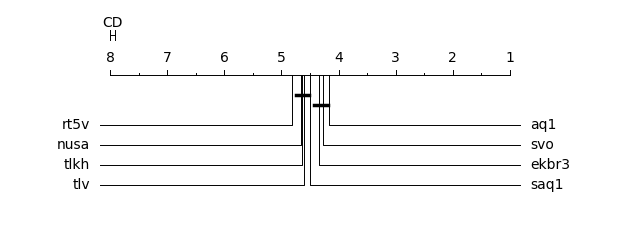

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15012.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 15012 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), ekbr3 (p=0.000), aq1 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


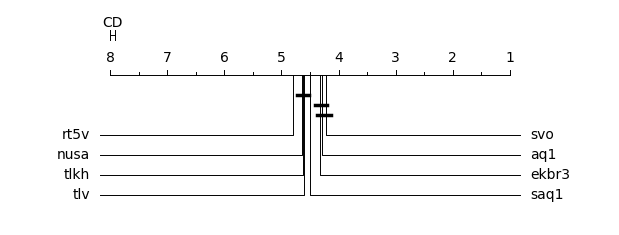

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15012.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 15012 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), aq1 (p=0.000), ekbr3 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


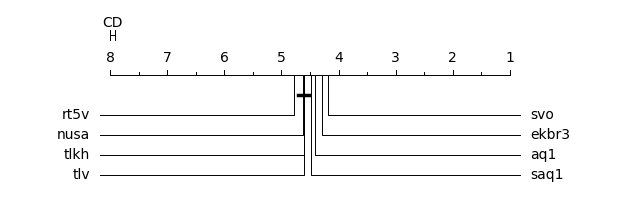

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15012.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 15012 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations ekbr3 (p=0.000), rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


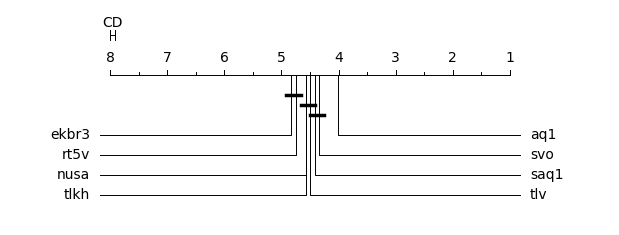

In [6]:
for alg_metric in data['metric'].unique():
    run_cd_selection_autorank(data, filter_name = 'metric', alg_metric_filter=alg_metric, alpha=0.05)

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30024.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 30024 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), ekbr3 (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


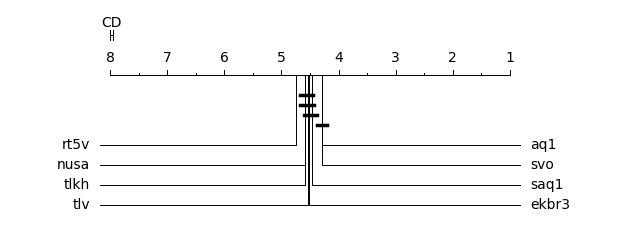

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30024.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 30024 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), nusa (p=0.000), tlkh (p=0.000), tlv (p=0.000), ekbr3 (p=0.000), saq1 (p=0.000), svo (p=0.000), and aq1 (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


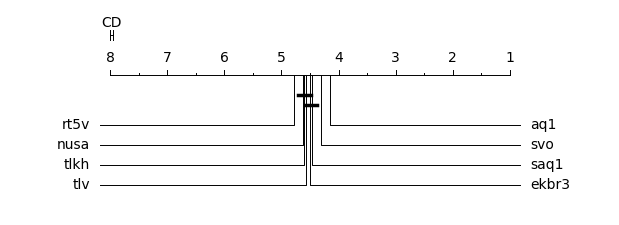

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30024.
  res = hypotest_fun_out(*samples, **kwds)


The statistical analysis was conducted for 8 populations with 30024 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations rt5v (p=0.000), tlkh (p=0.000), nusa (p=0.000), tlv (p=0.000), ekbr3 (p=0.000), saq1 (p=0.000), aq1 (p=0.000), and svo (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.0

/Users/andreamaldonado/miniconda3/envs/shampu/lib/python3.9/site-packages/autorank/_util.py:114: RuntimeWarning: invalid value encountered in double_scalars
  return (np.median(x) - np.median(y)) / _pooled_mad(x, y)


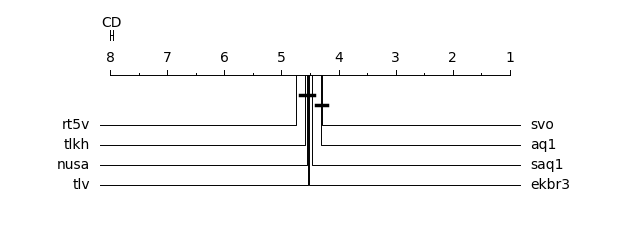

In [7]:
for alg_metric in data['algorithm'].unique():
    run_cd_selection_autorank(data, filter_name = 'algorithm', alg_metric_filter=alg_metric, alpha=0.05)

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_10529/1736415675.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('tab10', num_labels)


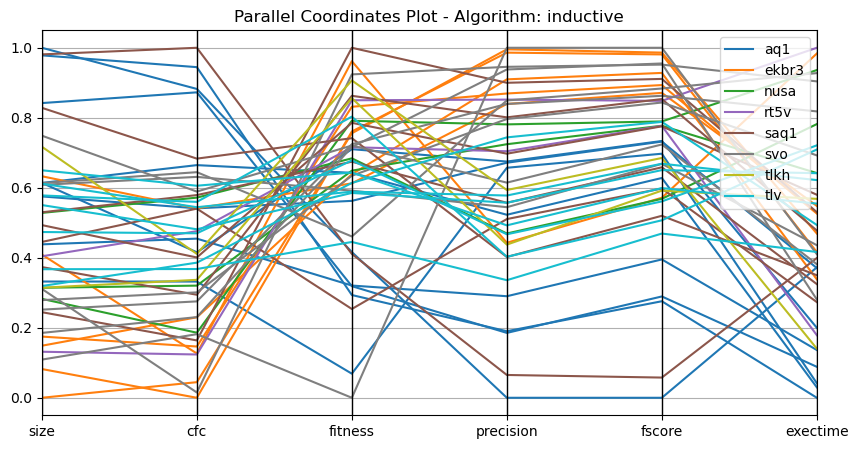

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_10529/1736415675.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('tab10', num_labels)


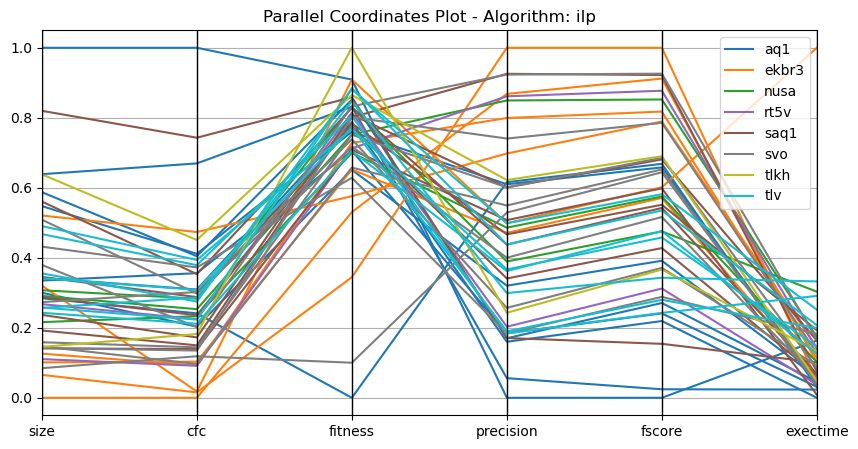

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_10529/1736415675.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('tab10', num_labels)


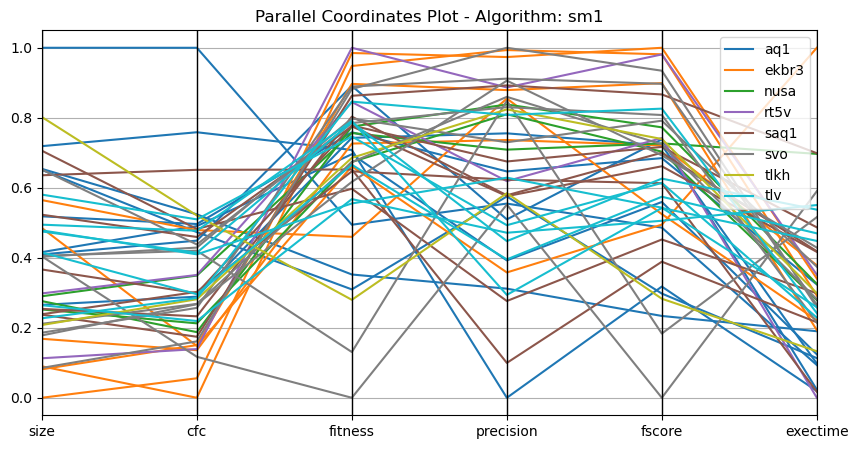

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

def run_coordinates_plot(data, algorithm_filter='inductive', exclude_metrics=None, normalize=True):
    """
    Create a parallel coordinates plot from shapley data filtered by algorithm.

    Parameters:
    - data: pd.DataFrame with columns ['algorithm', 'metric', 'feature_name', 'feature_value', 'shapley_value']
    - algorithm_filter: str, algorithm to filter by (default 'inductive')
    - exclude_metrics: list of str, metrics to exclude from data (default ['benchtime', 'pnsize'])
    - normalize: bool, whether to normalize metric columns before plotting (default True)
    """
    if exclude_metrics is None:
        exclude_metrics = ['benchtime', 'pnsize']

    # Filter data
    shapley = data[~data['metric'].isin(exclude_metrics)]
    cd_selection = shapley[shapley['algorithm'] == algorithm_filter]

    # Select relevant columns
    cd_selection = cd_selection[['feature_name', 'feature_value',
                                 'shapley_value', 'metric']].reset_index(drop=True)

    # Add id for pivot uniqueness
    cd_selection['id'] = cd_selection.groupby(['feature_name', 'feature_value']).cumcount()

    # Pivot to wide format
    wide_df = cd_selection.pivot_table(
        index=['feature_name', 'feature_value'],
        columns='metric',
        values='shapley_value',
        aggfunc='mean'
    ).reset_index()

    # Rename feature_name to Label for plotting
    wide_df = wide_df.rename(columns={'feature_name': 'Label'})

    # Fill NaNs with 0
    #wide_df = wide_df.fillna(0)
    #print(wide_df)

    # Define metrics columns to plot (adjust if your data has different columns)
    metrics = ['size', 'cfc', 'fitness', 'precision','fscore','exectime']
    wide_df = wide_df[['Label'] + metrics]

    # Normalize if requested
    if normalize:
        scaler = MinMaxScaler()
        wide_df[metrics] = scaler.fit_transform(wide_df[metrics])

    # Prepare colors
    labels = wide_df['Label'].unique()
    num_labels = len(labels)
    color_map = cm.get_cmap('tab10', num_labels)
    colors = [color_map(i) for i in range(num_labels)]

    # Plot
    plt.figure(figsize=(10, 5))
    parallel_coordinates(wide_df, 'Label', color=colors)
    plt.title(f'Parallel Coordinates Plot - Algorithm: {algorithm_filter}')
    plt.grid(True)
    plt.savefig(f"../output/plots/coord_{algorithm_filter}.png", dpi=300, bbox_inches='tight')

    plt.show()
run_coordinates_plot(data, algorithm_filter='inductive')
run_coordinates_plot(data, algorithm_filter='ilp')
run_coordinates_plot(data, algorithm_filter='sm1')